In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("/content/titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Q1. Create a simple line plot showing the count of passengers
who survived vs. did not survive over different passenger
classes (Pclass). Label axes and add a title. Interpret the trend
observed.


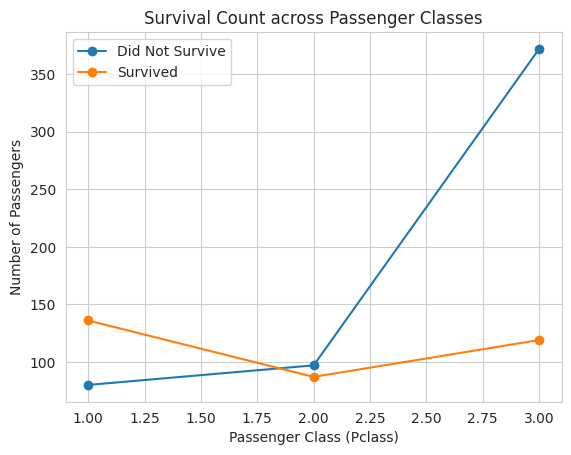

In [29]:
survival_counts = data.groupby(['Pclass', 'Survived']).size().unstack()
survival_counts.plot(kind='line', marker='o')
plt.xlabel("Passenger Class (Pclass)")
plt.ylabel("Number of Passengers")
plt.title("Survival Count across Passenger Classes")
plt.legend(["Did Not Survive", "Survived"])
plt.show()

Conclusion:

Passengers in 1st class survived more, while 3rd class had more deaths. This shows higher class had better survival chances.

Q2. Generate a scatter plot of &#39;Age&#39; vs. &#39;Fare&#39; for all passengers.
Color the data points based on survival status. Add a legend
and analyze the visible clusters.

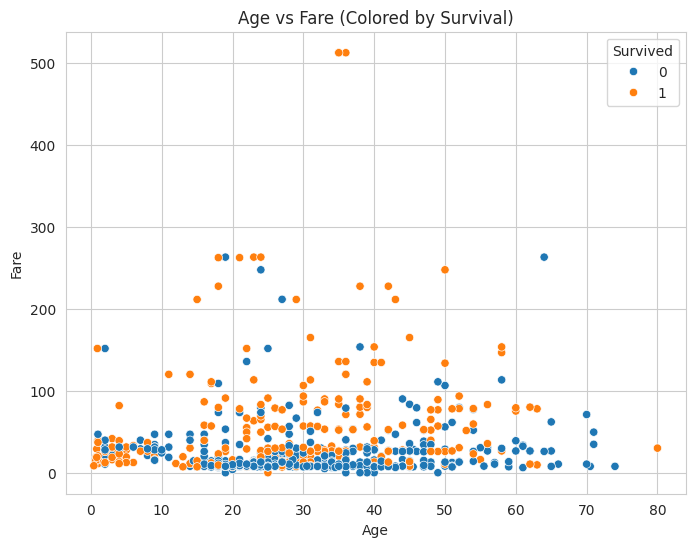

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='Age', y='Fare', hue='Survived')
plt.title("Age vs Fare (Colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

Conclusion:

Passengers who paid higher fares (mostly 1st class) had higher survival. Clear clusters show survival is related to fare.

Q3. Visualize the age distribution using a histogram with
appropriate bin sizes. Overlay a density curve using Seaborn&#39;s
histplot. Compare the age distributions of survivors vs. non-
survivors.

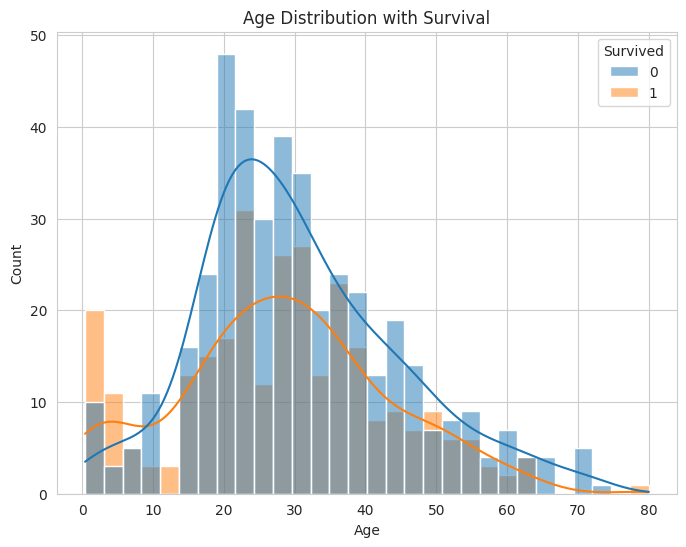

In [31]:
plt.figure(figsize=(8,6))
sns.histplot(data=data, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution with Survival")
plt.xlabel("Age")
plt.show()

Conclusion:

Younger passengers had slightly better survival. Most passengers are in 20–40 age range.

Q4. Create a density plot (KDE) of &#39;Fare&#39; grouped by passenger
class using Seaborn. Identify which class shows the widest
spread and what it implies.

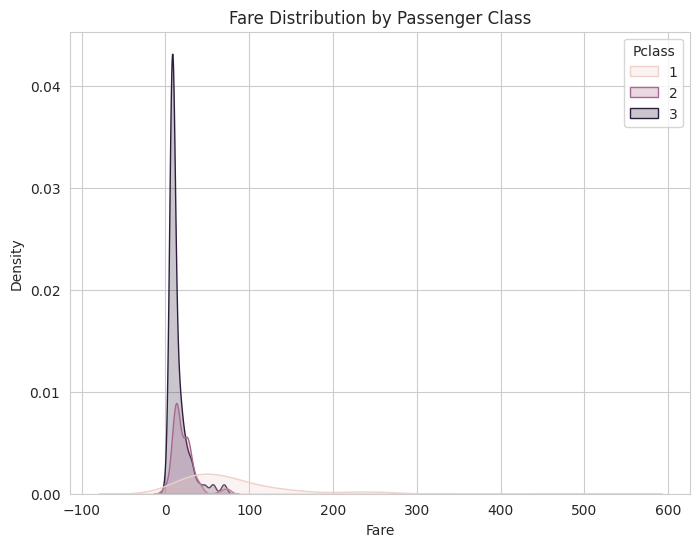

In [32]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=data, x='Fare', hue='Pclass', fill=True)
plt.title("Fare Distribution by Passenger Class")
plt.show()

Conclusion:

1st class has widest spread of fares, meaning rich passengers paid very high fares. Lower classes have limited range.

Q5. Generate a contour plot (using plt.contourf) representing the
2D distribution of &#39;Age&#39; and &#39;Fare&#39;. Interpret what the dense
regions indicate about typical passengers.

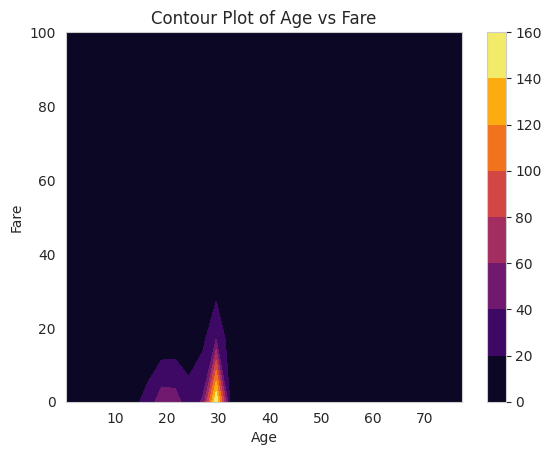

In [33]:
age = data['Age'].fillna(data['Age'].mean())
fare = data['Fare']
x = age.values
y = fare.values
z, xedges, yedges = np.histogram2d(x, y, bins=30)
plt.contourf(xedges[:-1], yedges[:-1], z.T, cmap='inferno')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Contour Plot of Age vs Fare")
plt.ylim(0, 100)
plt.colorbar()
plt.show()

Conclusion:

Most passengers are concentrated in low fare and middle age groups. Dense regions indicate that the majority traveled in lower classes, while fewer passengers with high fares are scattered.


Q6. Use Seaborn&#39;s pairplot to visualize relationships among
&#39;Age&#39;, &#39;Fare&#39;, &#39;SibSp&#39;, and &#39;Parch&#39; grouped by &#39;Survived&#39;. Highlight
the most discriminative feature pairs.

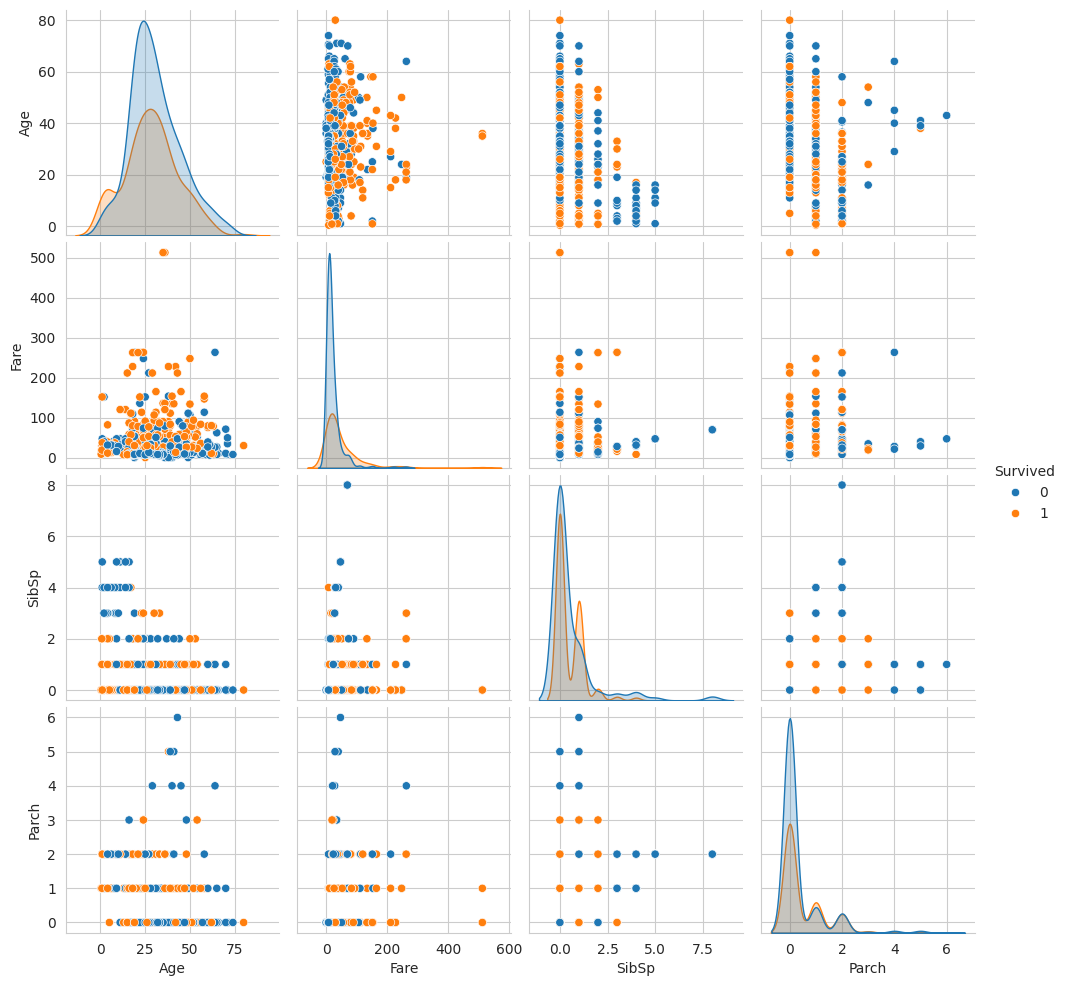

In [34]:
sns.pairplot(data[['Age','Fare','SibSp','Parch','Survived']], hue='Survived')
plt.show()

Conclusion:

Fare and Age are most important features. Survivors are more visible in higher fare ranges.

Q7. Create multiple subplots (2x2) showing: (a) histogram of

Age, (b) bar chart of survival by Sex, (c) boxplot of Fare by
Pclass, (d) countplot of Embarked. Organize with proper titles.

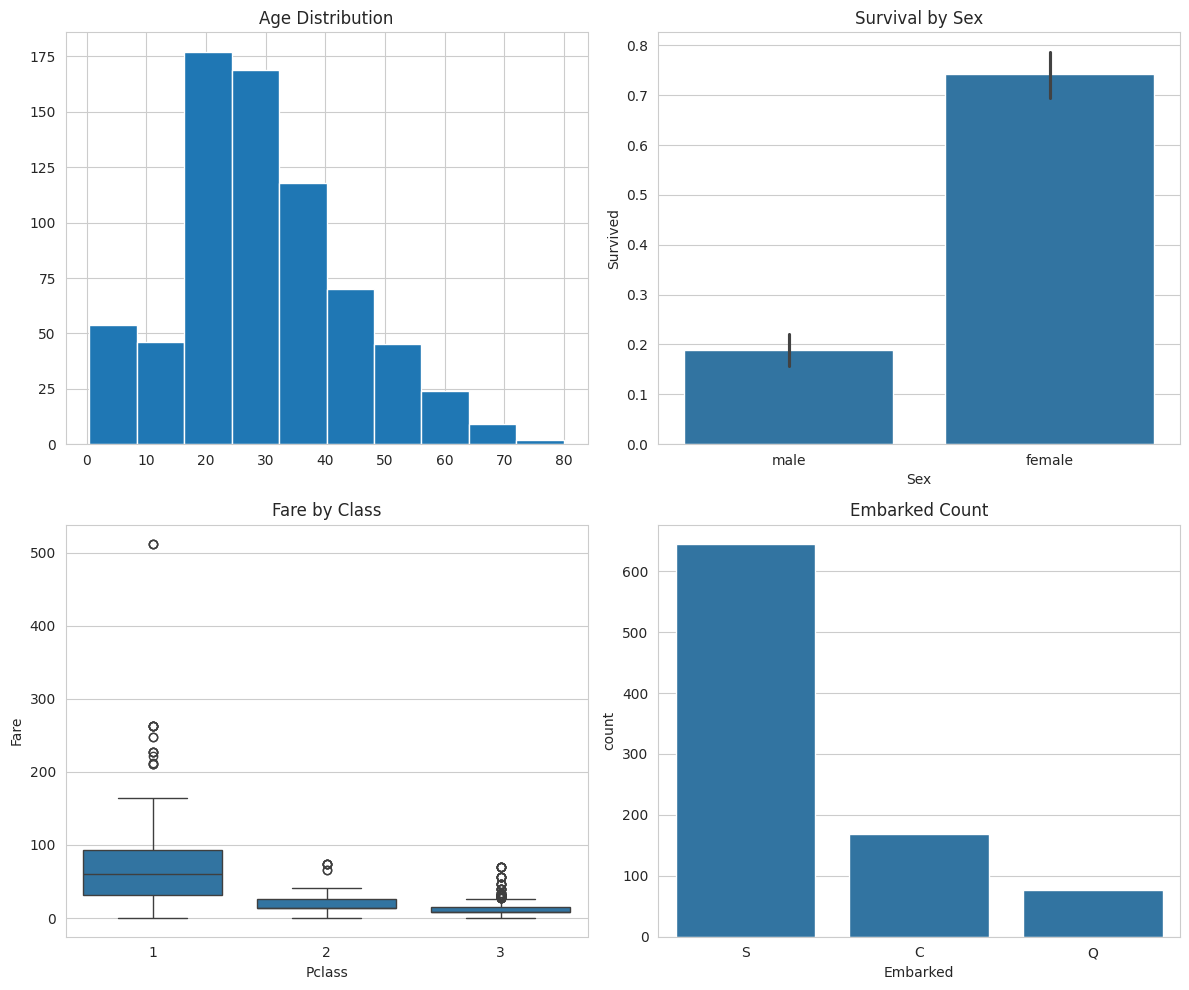

In [35]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.hist(data['Age'].dropna())
plt.title("Age Distribution")
plt.subplot(2,2,2)
sns.barplot(data=data, x='Sex', y='Survived')
plt.title("Survival by Sex")
plt.subplot(2,2,3)
sns.boxplot(data=data, x='Pclass', y='Fare')
plt.title("Fare by Class")
plt.subplot(2,2,4)
sns.countplot(data=data, x='Embarked')
plt.title("Embarked Count")
plt.tight_layout()
plt.show()

Conclusion:


*  Females survived more
*  Higher class paid more fare
*  Most passengers embarked from S







Q8. Visualize error bars by computing the mean and standard
deviation of &#39;Fare&#39; for each Pclass. Plot a bar chart with error
bars to represent variability in fare across classes.

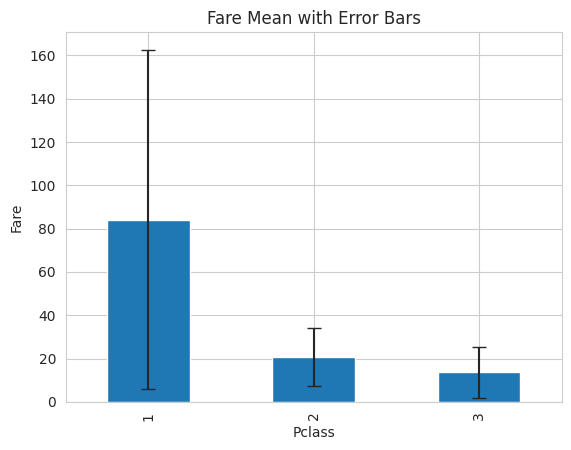

In [36]:
fare_stats = data.groupby('Pclass')['Fare'].agg(['mean','std'])
fare_stats['mean'].plot(kind='bar', yerr=fare_stats['std'], capsize=5)
plt.title("Fare Mean with Error Bars")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

Conclusion:

1st class shows high variation in fare, meaning unequal pricing among rich passengers.

Q9. Use Seaborn&#39;s heatmap to display the correlation matrix of
numeric columns in the Titanic dataset. Annotate cells and
identify the most strongly correlated feature pairs.

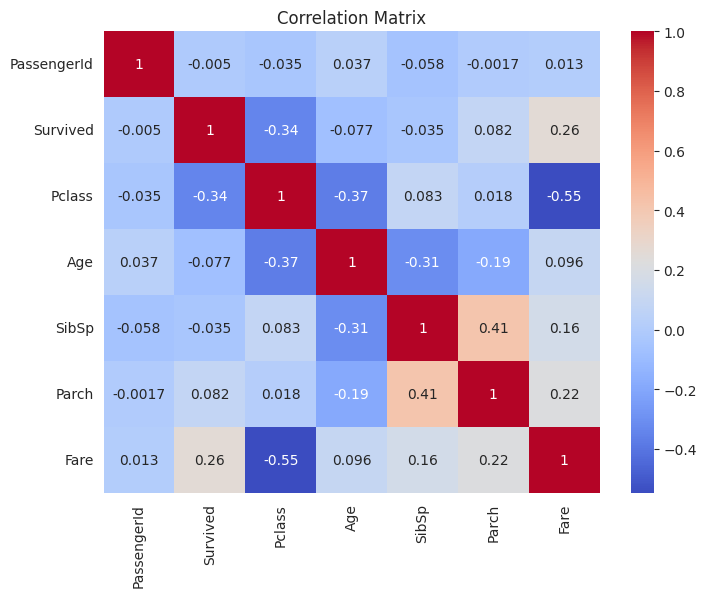

In [37]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Conclusion:

* Fare and Pclass are strongly related
* Survival is slightly correlated with Fare and class


Q10. Create a Seaborn catplot comparing survival rates by &#39;Sex&#39;
and &#39;Pclass&#39; using a bar plot with confidence intervals. Discuss
the interaction between gender and class on survival. Upload
the complete notebook to GitHub.

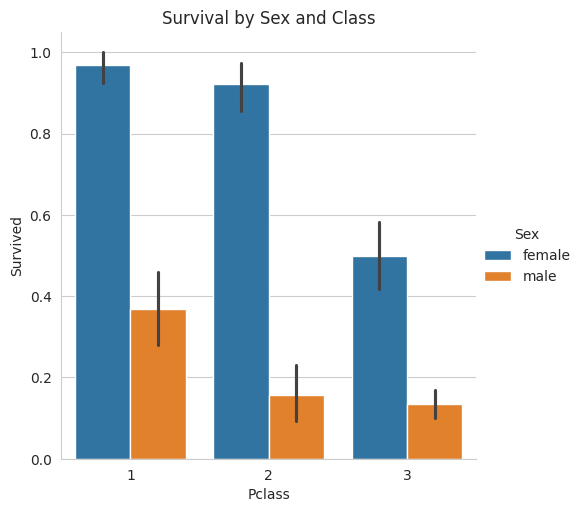

In [38]:
sns.catplot(data=data, x='Pclass', y='Survived', hue='Sex', kind='bar')
plt.title("Survival by Sex and Class")
plt.show()

Conclusion:

Females in all classes survived more, especially 1st class women had highest survival.